[*********************100%***********************]  1 of 1 completed


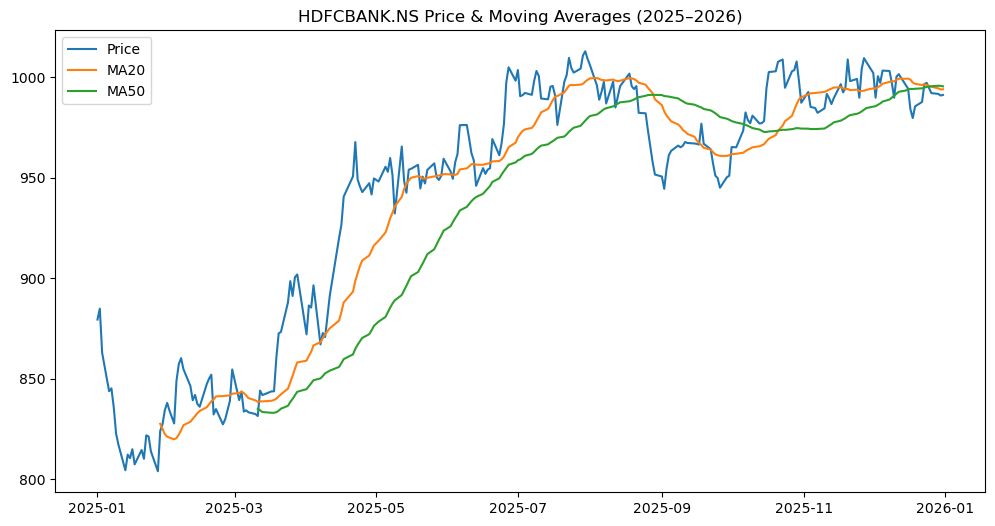

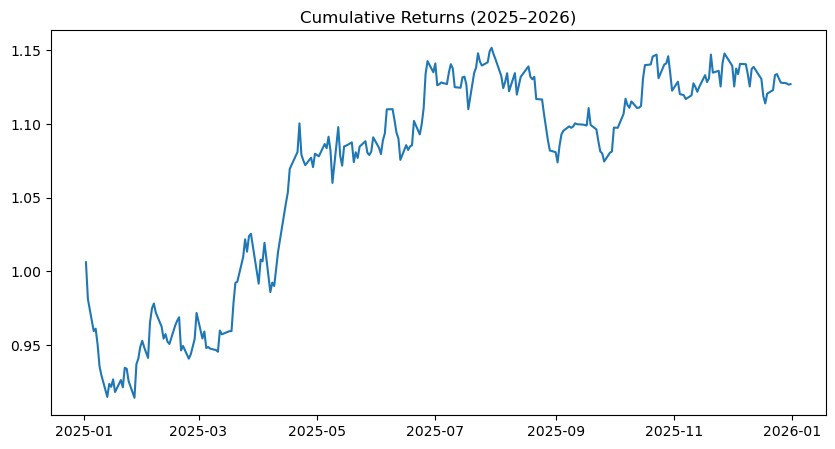

Stock: HDFCBANK.NS
Period: 1 Jan 2025 – 1 Jan 2026
Annualized Volatility: 15.59%
Latest Signal: SELL


In [3]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------
# 1. Download Stock Data
# -------------------------------
symbol = "HDFCBANK.NS"
data = yf.download(
    symbol,
    start="2025-01-01",
    end="2026-01-01",
    auto_adjust=True   # IMPORTANT
)

# -------------------------------
# 2. Data Cleaning
# -------------------------------
data.dropna(inplace=True)

# -------------------------------
# 3. Calculations (USE 'Close')
# -------------------------------
data['Daily Return'] = data['Close'].pct_change()
data['MA20'] = data['Close'].rolling(20).mean()
data['MA50'] = data['Close'].rolling(50).mean()

# Annualized Volatility
volatility = data['Daily Return'].std() * np.sqrt(252)

# Buy / Sell Signal
data['Signal'] = 0
data.loc[data['MA20'] > data['MA50'], 'Signal'] = 1
data.loc[data['MA20'] < data['MA50'], 'Signal'] = -1

# Cumulative Return
data['Cumulative Return'] = (1 + data['Daily Return']).cumprod()

# -------------------------------
# 4. Visualization
# -------------------------------
plt.figure(figsize=(12,6))
plt.plot(data['Close'], label='Price')
plt.plot(data['MA20'], label='MA20')
plt.plot(data['MA50'], label='MA50')
plt.title(f"{symbol} Price & Moving Averages (2025–2026)")
plt.legend()
plt.show()

plt.figure(figsize=(10,5))
plt.plot(data['Cumulative Return'])
plt.title("Cumulative Returns (2025–2026)")
plt.show()

# -------------------------------
# 5. Output
# -------------------------------
print("Stock:", symbol)
print("Period: 1 Jan 2025 – 1 Jan 2026")
print(f"Annualized Volatility: {volatility:.2%}")

signal = data['Signal'].iloc[-1]
print("Latest Signal:", "BUY" if signal == 1 else "SELL" if signal == -1 else "HOLD")


[*********************100%***********************]  1 of 1 completed


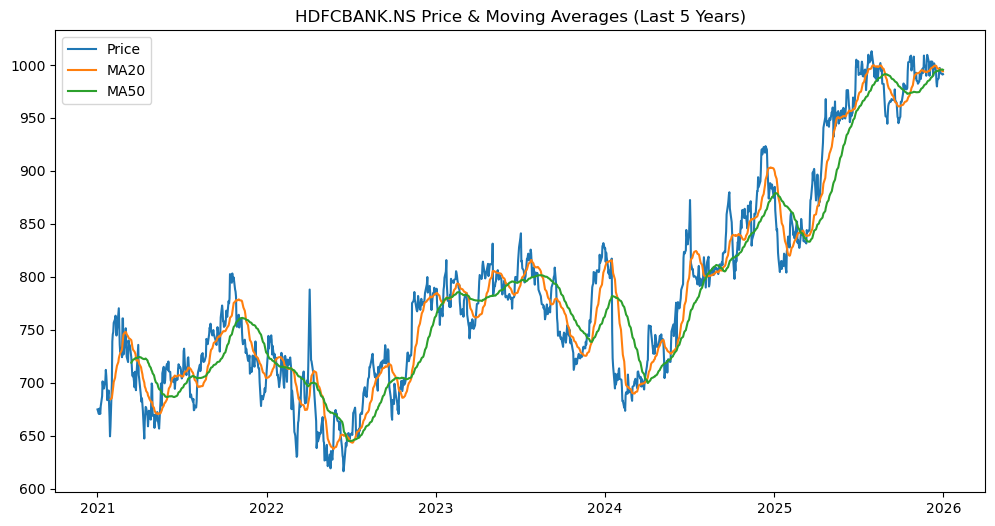

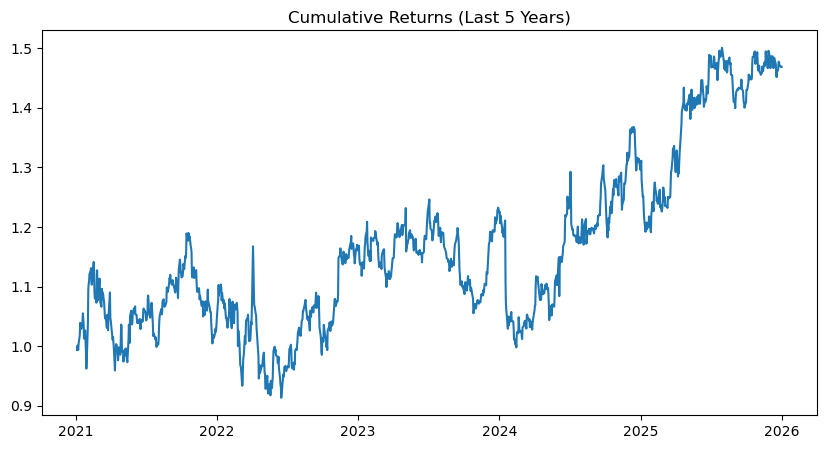

Stock: HDFCBANK.NS
Period: 2021-01-01 to 2026-01-01
Annualized Volatility: 21.24%
Latest Signal: SELL


In [4]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
from dateutil.relativedelta import relativedelta

# -------------------------------
# 1. Define Dates (5 Years Back)
# -------------------------------
end_date = datetime(2026, 1, 1)          # fixed end date
start_date = end_date - relativedelta(years=5)

# -------------------------------
# 2. Download Stock Data
# -------------------------------
symbol = "HDFCBANK.NS"
data = yf.download(
    symbol,
    start=start_date.strftime("%Y-%m-%d"),
    end=end_date.strftime("%Y-%m-%d"),
    auto_adjust=True
)

# -------------------------------
# 3. Data Cleaning
# -------------------------------
data.dropna(inplace=True)

# -------------------------------
# 4. Calculations
# -------------------------------
data['Daily Return'] = data['Close'].pct_change()
data['MA20'] = data['Close'].rolling(20).mean()
data['MA50'] = data['Close'].rolling(50).mean()

# Annualized Volatility
volatility = data['Daily Return'].std() * np.sqrt(252)

# Buy / Sell Signal
data['Signal'] = 0
data.loc[data['MA20'] > data['MA50'], 'Signal'] = 1
data.loc[data['MA20'] < data['MA50'], 'Signal'] = -1

# Cumulative Return
data['Cumulative Return'] = (1 + data['Daily Return']).cumprod()

# -------------------------------
# 5. Visualization
# -------------------------------
plt.figure(figsize=(12,6))
plt.plot(data['Close'], label='Price')
plt.plot(data['MA20'], label='MA20')
plt.plot(data['MA50'], label='MA50')
plt.title(f"{symbol} Price & Moving Averages (Last 5 Years)")
plt.legend()
plt.show()

plt.figure(figsize=(10,5))
plt.plot(data['Cumulative Return'])
plt.title("Cumulative Returns (Last 5 Years)")
plt.show()

# -------------------------------
# 6. Output
# -------------------------------
print("Stock:", symbol)
print(f"Period: {start_date.date()} to {end_date.date()}")
print(f"Annualized Volatility: {volatility:.2%}")

signal = data['Signal'].iloc[-1]
print("Latest Signal:", "BUY" if signal == 1 else "SELL" if signal == -1 else "HOLD")


[*********************100%***********************]  1 of 1 completed
C:\Users\User\AppData\Local\Temp\ipykernel_1952\210393394.py:51: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  entry_price = float(data['Open'].iloc[i])
C:\Users\User\AppData\Local\Temp\ipykernel_1952\210393394.py:66: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  low = float(data['Low'].iloc[j])
C:\Users\User\AppData\Local\Temp\ipykernel_1952\210393394.py:67: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  high = float(data['High'].iloc[j])
C:\Users\User\AppData\Local\Temp\ipykernel_1952\210393394.py:68: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.

===== BACKTEST RESULT =====
Stock: HDFCBANK.NS
Total Trades: 17
Win Rate (Accuracy): 35.29%
Total Profit (₹): -324.26


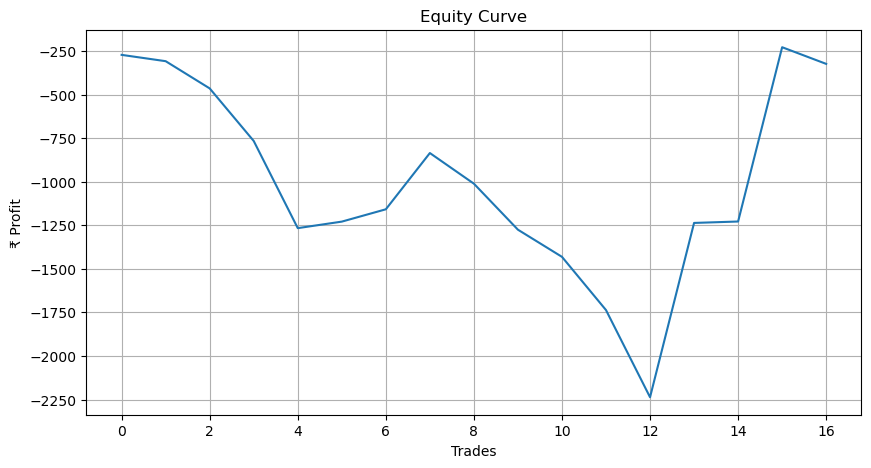

In [6]:
import yfinance as yf
import pandas as pd
import numpy as np
from datetime import datetime
from dateutil.relativedelta import relativedelta
import matplotlib.pyplot as plt

# --------------------------
# Parameters
# --------------------------
symbol = "HDFCBANK.NS"
end_date = datetime(2026, 1, 1)
start_date = end_date - relativedelta(years=5)

capital_per_trade = 5000
risk_per_trade = 500
reward_per_trade = 1000

# --------------------------
# Download data
# --------------------------
data = yf.download(
    symbol,
    start=start_date.strftime("%Y-%m-%d"),
    end=end_date.strftime("%Y-%m-%d"),
    auto_adjust=True
)

data.dropna(inplace=True)

# --------------------------
# Indicators
# --------------------------
data['MA20'] = data['Close'].rolling(20).mean()
data['MA50'] = data['Close'].rolling(50).mean()

data['ma_cross_up'] = (
    (data['MA20'] > data['MA50']) &
    (data['MA20'].shift(1) <= data['MA50'].shift(1))
)

# --------------------------
# Backtest
# --------------------------
trades = []
in_trade = False
i = 0

while i < len(data):
    if not in_trade and data['ma_cross_up'].iloc[i]:
        entry_price = float(data['Open'].iloc[i])
        entry_date = data.index[i]

        qty = int(capital_per_trade / entry_price)
        if qty == 0:
            i += 1
            continue

        stop_price = entry_price - (risk_per_trade / qty)
        target_price = entry_price + (reward_per_trade / qty)

        in_trade = True
        j = i + 1

    elif in_trade:
        low = float(data['Low'].iloc[j])
        high = float(data['High'].iloc[j])
        close = float(data['Close'].iloc[j])
        exit_date = data.index[j]

        if low <= stop_price:
            exit_price = stop_price
            reason = "SL"
        elif high >= target_price:
            exit_price = target_price
            reason = "TARGET"
        elif data['MA20'].iloc[j] < data['MA50'].iloc[j]:
            exit_price = close
            reason = "MA_EXIT"
        else:
            j += 1
            if j >= len(data):
                break
            continue

        profit = (exit_price - entry_price) * qty

        trades.append({
            "Entry Date": entry_date,
            "Exit Date": exit_date,
            "Entry Price": entry_price,
            "Exit Price": exit_price,
            "Qty": qty,
            "Profit": profit,
            "Reason": reason
        })

        in_trade = False
        i = j

    else:
        i += 1

# --------------------------
# Results
# ----------------  
# --------------------------
trades_df = pd.DataFrame(trades)

if trades_df.empty:
    print("No trades generated.")
else:
    total_trades = len(trades_df)
    wins = (trades_df['Profit'] > 0).sum()
    win_rate = wins / total_trades
    total_profit = trades_df['Profit'].sum()

    print("===== BACKTEST RESULT =====")
    print("Stock:", symbol)
    print("Total Trades:", total_trades)
    print(f"Win Rate (Accuracy): {win_rate:.2%}")
    print(f"Total Profit (₹): {total_profit:.2f}")

    # Equity curve
    trades_df['Cumulative Profit'] = trades_df['Profit'].cumsum()

    plt.figure(figsize=(10,5))
    plt.plot(trades_df['Cumulative Profit'])
    plt.title("Equity Curve")
    plt.xlabel("Trades")
    plt.ylabel("₹ Profit")
    plt.grid()
    plt.show()


In [1]:
pip install yfinance pandas numpy


In [3]:
import yfinance as yf
import pandas as pd
import numpy as np

# ==============================
# PARAMETERS
# ==============================
SYMBOL = "^NSEI"
INTERVAL = "1m"
PERIOD = "7d"
BODY_MULTIPLIER = 1.5

# ==============================
# DOWNLOAD DATA
# ==============================
df = yf.download(
    SYMBOL,
    interval=INTERVAL,
    period=PERIOD,
    progress=False
)

# 🔴 FIX: flatten columns
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

df.dropna(inplace=True)
df['time'] = df.index.time

# ==============================
# OPENING RANGE
# ==============================
or_df = df.between_time("09:15", "09:30")
ORH = or_df['High'].max()
ORL = or_df['Low'].min()

# ==============================
# DISPLACEMENT
# ==============================
df['body'] = (df['Close'] - df['Open']).abs()
df['avg_body'] = df['body'].rolling(20).mean()

df['bearish_displacement'] = (
    (df['Close'] < df['Open']) &
    (df['body'] > BODY_MULTIPLIER * df['avg_body'])
)

# ==============================
# BEARISH FVG
# ==============================
df['bearish_fvg'] = (
    df['Low'].shift(1) > df['High'].shift(-1)
)

# ==============================
# BACKTEST
# ==============================
trades = []

for i in range(30, len(df)-1):
    row = df.iloc[i]

    if row['High'] > ORH and row['bearish_displacement'] and row['bearish_fvg']:
        entry = row['Close']
        sl = row['High']
        target = ORL

        for j in range(i+1, len(df)):
            candle = df.iloc[j]

            if candle['High'] >= sl:
                trades.append(sl - entry)
                break

            if candle['Low'] <= target:
                trades.append(target - entry)
                break

# ==============================
# RESULTS
# ==============================
if trades:
    trades = np.array(trades)
    print("Total Trades:", len(trades))
    print("Wins:", (trades < 0).sum())
    print("Losses:", (trades > 0).sum())
    print("Net Points:", trades.sum())
else:
    print("No trades found")



C:\Users\User\AppData\Local\Temp\ipykernel_5240\4225682176.py:16: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(


No trades found
